In [1]:
import pandas as pd
df = pd.read_csv("20250101_20251231_Tucson.lev20", skiprows=6)
df['Datetime'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'],
                                format='%d:%m:%Y %H:%M:%S')
df[['Datetime', 'AOD_500nm', '440-870_Angstrom_Exponent']].head()


,Datetime,AOD_500nm,440-870_Angstrom_Exponent
0,2025-01-01 16:09:58,0.031839,0.732349
1,2025-01-01 16:12:57,0.027653,0.966127
2,2025-01-01 16:16:13,0.027424,0.941475
3,2025-01-01 16:22:57,0.026849,0.912493
4,2025-01-01 16:24:59,0.026972,0.919893


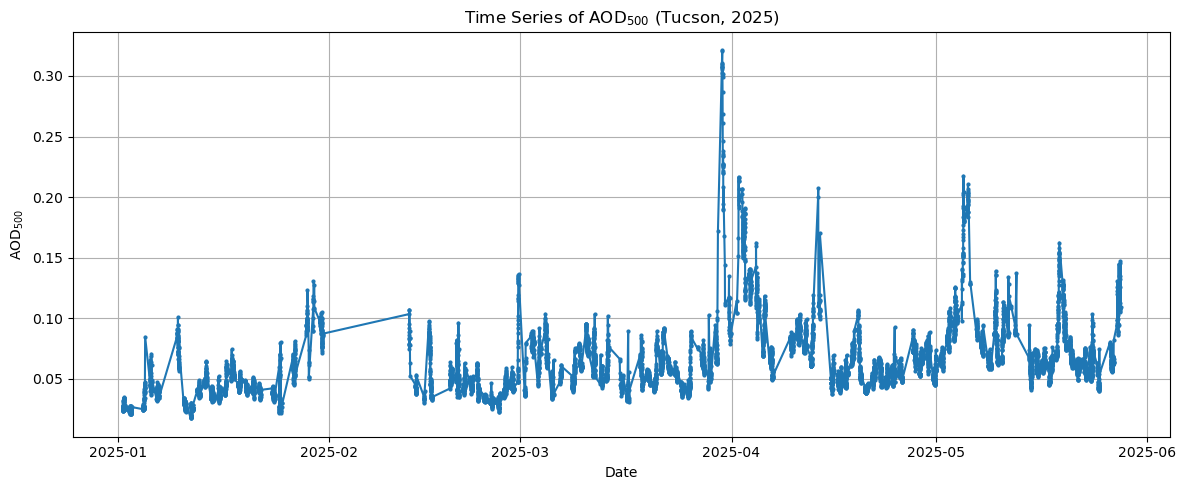

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load data
file_path = "20250101_20251231_Tucson.lev20"
df = pd.read_csv(file_path, delimiter=',', header=0, skiprows=6)

# Step 2: Parse datetime
df['Datetime'] = pd.to_datetime(df['Date(dd:mm:yyyy)'] + ' ' + df['Time(hh:mm:ss)'],
                                format='%d:%m:%Y %H:%M:%S')

# Step 3: Replace invalid values
df.replace(-999.0, np.nan, inplace=True)

# Step 4: Sort by datetime (just in case)
df = df.sort_values('Datetime')

# Step 5: Plot time series for AOD_500nm
plt.figure(figsize=(12, 5))
plt.plot(df['Datetime'], df['AOD_500nm'], linestyle='-', marker='o', markersize=2)
plt.xlabel("Date")
plt.ylabel("AOD$_{500}$")
plt.title("Time Series of AOD$_{500}$ (Tucson, 2025)")
plt.grid(True)
plt.tight_layout()
plt.show()


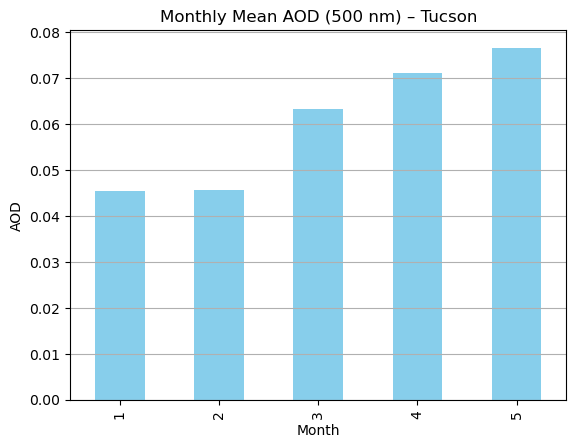

In [4]:
df['Month'] = df['Datetime'].dt.month
monthly_mean = df.groupby('Month')['AOD_500nm'].mean()

monthly_mean.plot(kind='bar', color='skyblue')
plt.title('Monthly Mean AOD (500 nm) – Tucson')
plt.xlabel('Month')
plt.ylabel('AOD')
plt.grid(axis='y')
plt.show()


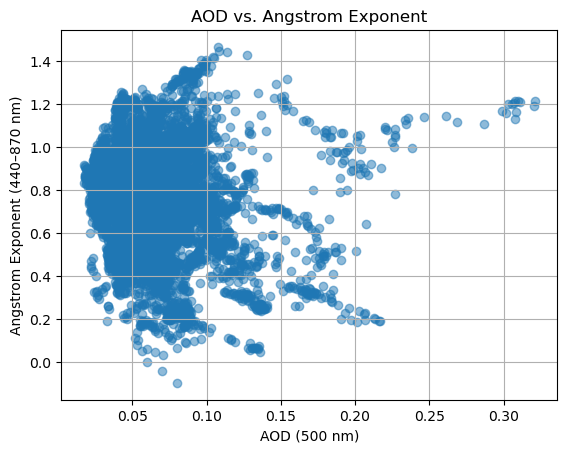

In [5]:
plt.scatter(df['AOD_500nm'], df['440-870_Angstrom_Exponent'], alpha=0.5)
plt.xlabel('AOD (500 nm)')
plt.ylabel('Angstrom Exponent (440–870 nm)')
plt.title('AOD vs. Angstrom Exponent')
plt.grid(True)
plt.show()


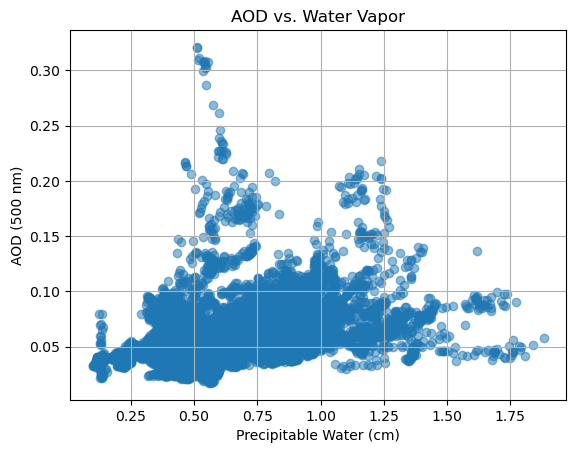

In [6]:
plt.scatter(df['Precipitable_Water(cm)'], df['AOD_500nm'], alpha=0.5)
plt.xlabel('Precipitable Water (cm)')
plt.ylabel('AOD (500 nm)')
plt.title('AOD vs. Water Vapor')
plt.grid(True)
plt.show()


In [7]:
import folium

lat = df['Site_Latitude(Degrees)'].iloc[0]
lon = df['Site_Longitude(Degrees)'].iloc[0]

m = folium.Map(location=[lat, lon], zoom_start=10)
folium.Marker([lat, lon], popup='Tucson AERONET Station').add_to(m)
m


ModuleNotFoundError: No module named 'folium'